In [1]:
import os
import random
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA


class KLLSketch:
    """
    KLL Sketch as in Karnin, Lang, and Liberty (Optimal Quantile Approximation in Streams).
    Key features:
      1) Each level h has capacity_k(h) that typically shrinks as h decreases.
      2) Each compaction randomly discards either odd or even indices, ensuring unbiased rank error.
      3) Mergeability: We can merge two sketches by concatenating levels and re-compacting as needed.

    Usage:
      - Initialize with (k, c, ...).
      - Call update(value) or batch_update(...) to feed data.
      - get_quantile(q) and get_cdf(...) approximate rank queries.
      - merge(other_sketch) merges two sketches (fully mergeable).
    """

    def __init__(self, k=50, c=0.75):
        """
        :param k:     'nominal' capacity for the top level.
        :param c:     shrinking factor in (0.5, 1). Lower c => smaller capacities at lower levels.
        """
        self.k = k
        self.c = c

        # Each entry in self.levels is a list of (value, weight) for that level
        self.levels = [[]]  # Start with just level 0
        self.total_weight = 0

    def update(self, val):
        """
        Insert a single value. Equivalent to batch_update([val]).
        """
        self.batch_update([val])

    def batch_update(self, data):
        """
        Insert multiple values at once:
          1. Sort them
          2. Turn into (val, weight=1)
          3. Merge into level 0
          4. If level 0 over capacity, compress it
        """
        if not data:
            return
        data_sorted = sorted(data)
        batch_pairs = [(v, 1) for v in data_sorted]
        self._merge_into_level(0, batch_pairs)
        self.total_weight += len(data)

        # Check capacity at level 0
        if len(self.levels[0]) > self._capacity_for_level(0):
            self._compress_level(0)

    def merge(self, other):
        """
        Fully merge 'other' sketch into 'self' by concatenating each level
        and re-compacting if we exceed capacity. Same approach used in KLL
        for mergeability.
        """
        max_lvls = max(len(self.levels), len(other.levels))
        while len(self.levels) < max_lvls:
            self.levels.append([])
        while len(other.levels) < max_lvls:
            other.levels.append([])

        for lvl in range(max_lvls):
            self.levels[lvl].extend(other.levels[lvl])
            if len(self.levels[lvl]) > self._capacity_for_level(lvl):
                self._compress_level(lvl)

        self.total_weight += other.total_weight

    def get_quantile(self, q):
        """
        Approximate the q-th quantile (0 <= q <= 1).
        Flatten all levels, sort by value, then pick item by prefix sum over weights.
        """
        if self.total_weight == 0:
            return None
        all_pairs = self._flatten()
        target = q * self.total_weight
        running = 0
        for val, w in all_pairs:
            running += w
            if running >= target:
                return val
        return all_pairs[-1][0]  # fallback if numeric rounding

    def get_cdf(self, values):
        """
        Approximate CDF(x) for each x in 'values'.
          CDF(x) = (# of items <= x) / total_weight.
        We'll flatten once, then walk through in sorted order.
        """
        if self.total_weight == 0:
            return [0.0] * len(values)
        all_pairs = self._flatten()

        results = []
        idx = 0
        running = 0
        n_pairs = len(all_pairs)
        for x in values:
            while idx < n_pairs and all_pairs[idx][0] <= x:
                running += all_pairs[idx][1]
                idx += 1
            results.append(running / self.total_weight)
        return results

    ### Internals: capacity schedules, compactions, flattening ###

    def _merge_into_level(self, lvl, new_pairs):
        # Ensure the level exists
        while lvl >= len(self.levels):
            self.levels.append([])
        self.levels[lvl].extend(new_pairs)

    def _compress_level(self, lvl):
        """
        KLL random compaction:
          1) Sort the level by value
          2) Flip a coin to keep either the even or odd indices
          3) The kept items have weight doubled
          4) Merge them into level (lvl+1)
          5) If next level is over capacity, compress it, etc.
        """
        if lvl + 1 >= len(self.levels):
            self.levels.append([])

        # Sort by value
        arr = self.levels[lvl]
        arr.sort(key=lambda x: x[0])

        # KLL discarding: pick even or odd
        keep_even = random.random() < 0.5

        compressed = []
        # step by 2
        for i in range(0, len(arr), 2):
            if keep_even:
                val, w = arr[i]
            else:
                # odd index i+1 might not exist if arr length is odd
                if i + 1 < len(arr):
                    val, w = arr[i + 1]
                else:
                    # standard KLL approach: if there's an unmatched item at the end,
                    # just keep it or treat it carefully. We'll just keep it here:
                    val, w = arr[i]

            compressed.append((val, w * 2))

        arr.clear()  # clear current level
        self._merge_into_level(lvl + 1, compressed)

        # If next level is beyond capacity, compress further
        if len(self.levels[lvl + 1]) > self._capacity_for_level(lvl + 1):
            self._compress_level(lvl + 1)

    def _flatten(self):
        """
        Flatten all levels into one sorted array of (value, weight).
        """
        merged = []
        for lvl_data in self.levels:
            merged.extend(lvl_data)
        merged.sort(key=lambda x: x[0])
        return merged

    def _capacity_for_level(self, lvl):
        """
        Following the KLL paper, we want smaller capacities at lower levels.
        One standard approach: capacity ~ k * c^(H - lvl).
        However, we don't know H in advance. A simple approximation:
           capacity(lvl) = max(2, floor( k * c^lvl ))
        or we can invert the exponent. There's no single official formula
        in the KLL text for code, but c^lvl or c^(H-lvl) are typical.
        """
        # Here, we let the capacity shrink as lvl grows:
        cap = int(self.k * (self.c**lvl))
        return max(cap, 2)


###############################################################################
# KLL-based KS Distance (use total_weight, not total_count)
###############################################################################
def kll_kolmogorov_smirnov_distance(sketchA, sketchB, num_grid=50):
    """
    Compare two 1D KLL sketches with an approximate KS distance
    over 'num_grid' test points.
    """
    # Check empty
    if sketchA.total_weight == 0 or sketchB.total_weight == 0:
        return 0.0

    # Get min / max from both distributions
    minA = sketchA.get_quantile(0.0)
    maxA = sketchA.get_quantile(1.0)
    minB = sketchB.get_quantile(0.0)
    maxB = sketchB.get_quantile(1.0)
    global_min = min(minA, minB)
    global_max = max(maxA, maxB)

    if global_min == global_max:
        return 0.0

    # Evaluate each sketch's CDF over a linspace
    test_vals = np.linspace(global_min, global_max, num_grid)
    cdfA = sketchA.get_cdf(test_vals)
    cdfB = sketchB.get_cdf(test_vals)
    return max(abs(a - b) for (a, b) in zip(cdfA, cdfB))


args = {
    "models": ["nlpaueb/sec-bert-base", "bert-base-uncased"],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text",
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text",
        },
        {"name": "ag_news", "config": None, "split": "train", "text_column": "text"},
    ],
    "max_texts": 100,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "data-analysis/data",
    "hist_bins": 30,
    "num_seeds": 3,
    "kl_eps": 1e-12,
    "use_adaptive_gamma": True,
    "kll_capacity": 50,
    "kll_num_grid": 50,
}

os.makedirs(args["output_dir"], exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]


def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()


def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts


def build_2d_hist(embs_2d, bins=30):
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0], embs_2d[:, 1], bins=bins, density=False
    )
    hist = hist / hist.sum()
    return hist, xedges, yedges


def safe_prob(p, eps=1e-12):
    return np.maximum(p, eps)


def kl_divergence(p, q, kl_eps=1e-12):
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    return np.sum(p_ * np.log(p_ / q_))


def js_divergence(p, q, kl_eps=1e-12):
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    m_ = 0.5 * (p_ + q_)
    return 0.5 * kl_divergence(p_, m_, kl_eps=kl_eps) + 0.5 * kl_divergence(
        q_, m_, kl_eps=kl_eps
    )


def bhattacharyya_distance(p, q, kl_eps=1e-12):
    bc = np.sum(np.sqrt(safe_prob(p, eps=kl_eps) * safe_prob(q, eps=kl_eps)))
    return -np.log(bc + 1e-12)


def compute_2d_hist_distance(
    baseline_embs, new_embs, measure="js", bins=30, kl_eps=1e-12
):
    hist_p, xedges, yedges = build_2d_hist(baseline_embs, bins=bins)
    hist_q_raw, _, _ = np.histogram2d(
        new_embs[:, 0], new_embs[:, 1], bins=[xedges, yedges], density=False
    )
    hist_q = hist_q_raw / hist_q_raw.sum()
    p = hist_p.flatten()
    q = hist_q.flatten()
    if measure == "kl":
        return kl_divergence(p, q, kl_eps=kl_eps)
    elif measure == "js":
        return js_divergence(p, q, kl_eps=kl_eps)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q, kl_eps=kl_eps)
    else:
        raise ValueError(f"Unknown measure: {measure}")


def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2 * np.dot(x, y.T)
    return np.exp(-gamma * dist2)


def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m, n = len(X), len(Y)
    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m * n)
    return np.sqrt(mmd2)


def auto_select_gamma(embs):
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample) - 1):
        dist2 = np.sum((sample[i] - sample[i + 1 :]) ** 2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0 / (2.0 * median_dist2)


def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    from scipy.stats import wasserstein_distance

    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum


###############################################################################
###############################################################################
def run_experiment_single_seed(seed, args):
    set_seed(seed)
    device = torch.device(
        "mps"
        if torch.backends.mps.is_available()
        else "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name, dataset_config, dataset_split, text_col = dataset_info.values()
        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts, drift_texts = texts[:half_point], texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device).eval()

            # 1) Build baseline embeddings
            baseline_embs = []
            for batch in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, batch, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # PCA -> 1D
            pca_1d = PCA(n_components=1).fit(baseline_embs)
            baseline_1d = pca_1d.transform(baseline_embs).flatten()

            # Build a KLL Sketch (k = capacity)
            baseline_sketch = KLLSketch(k=args["kll_capacity"], c=0.75)
            for val in baseline_1d:
                baseline_sketch.update(val)

            # Keep 2D for hist-based metrics
            pca_2d = PCA(n_components=args["pca_components"]).fit(baseline_embs)
            baseline_embs_2d = pca_2d.transform(baseline_embs)

            # MMD gamma
            gamma_val = (
                auto_select_gamma(baseline_embs) if args["use_adaptive_gamma"] else 0.5
            )

            # Distribution measures to compute
            distribution_measures = [
                "kl",
                "js",
                "bhattacharyya",
                "mmd",
                "wasserstein",
                "kll_ks",
            ]

            for measure_name in distribution_measures:
                for drift_strength in args["drift_strengths"]:
                    start_time = time.time()

                    # Introduce drift
                    drifted_texts_mod = introduce_gradual_drift(
                        drift_texts, drift_strength
                    )
                    drift_embs = []
                    for batch in batch_generator(drifted_texts_mod, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, batch, device)
                        drift_embs.append(emb_b)
                    drift_embs = np.concatenate(drift_embs, axis=0)

                    # PCA -> 1D for drift
                    drift_1d = pca_1d.transform(drift_embs).flatten()
                    drift_sketch = KLLSketch(k=args["kll_capacity"], c=0.75)
                    for val in drift_1d:
                        drift_sketch.update(val)

                    # 2D embeddings for hist-based or MMD-based metrics
                    drift_embs_2d = pca_2d.transform(drift_embs)

                    overhead_start = time.time()
                    if measure_name in ["kl", "js", "bhattacharyya"]:
                        dist_val = compute_2d_hist_distance(
                            baseline_embs_2d,
                            drift_embs_2d,
                            measure=measure_name,
                            bins=args["hist_bins"],
                            kl_eps=args["kl_eps"],
                        )
                    elif measure_name == "mmd":
                        dist_val = compute_mmd(
                            baseline_embs, drift_embs, gamma=gamma_val
                        )
                    elif measure_name == "wasserstein":
                        dist_val = compute_wasserstein_1D_per_dim(
                            baseline_embs_2d, drift_embs_2d
                        )
                    elif measure_name == "kll_ks":
                        # Compare the two KLLSketches
                        dist_val = kll_kolmogorov_smirnov_distance(
                            baseline_sketch, drift_sketch, num_grid=args["kll_num_grid"]
                        )
                    else:
                        dist_val = None

                    measure_overhead = time.time() - overhead_start
                    time_taken = time.time() - start_time

                    key = (dataset_name, model_name, measure_name, drift_strength)
                    results[key].append(
                        {
                            "dist_val": dist_val,
                            "time_taken": time_taken,
                            "measure_overhead": measure_overhead,
                            "seed": seed,
                        }
                    )

    return results


###############################################################################
# 6) Collect data across multiple seeds
###############################################################################
def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = run_experiment_single_seed(seed, args)
        for k, list_of_records in seed_results.items():
            all_results[k].extend(list_of_records)
    print("Data collection (all seeds) done!")
    return all_results


# Finally, run everything:
all_results = collect_data_multiple_seeds(args)

/Users/jasper.bruin/Documents/driftwatch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=1] Using device: mps
[Seed=1] === Loading dataset: yelp_review_full ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: wikitext ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: ag_news ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=2] Using device: mps
[Seed=2] === Loading dataset: yelp_review_full 

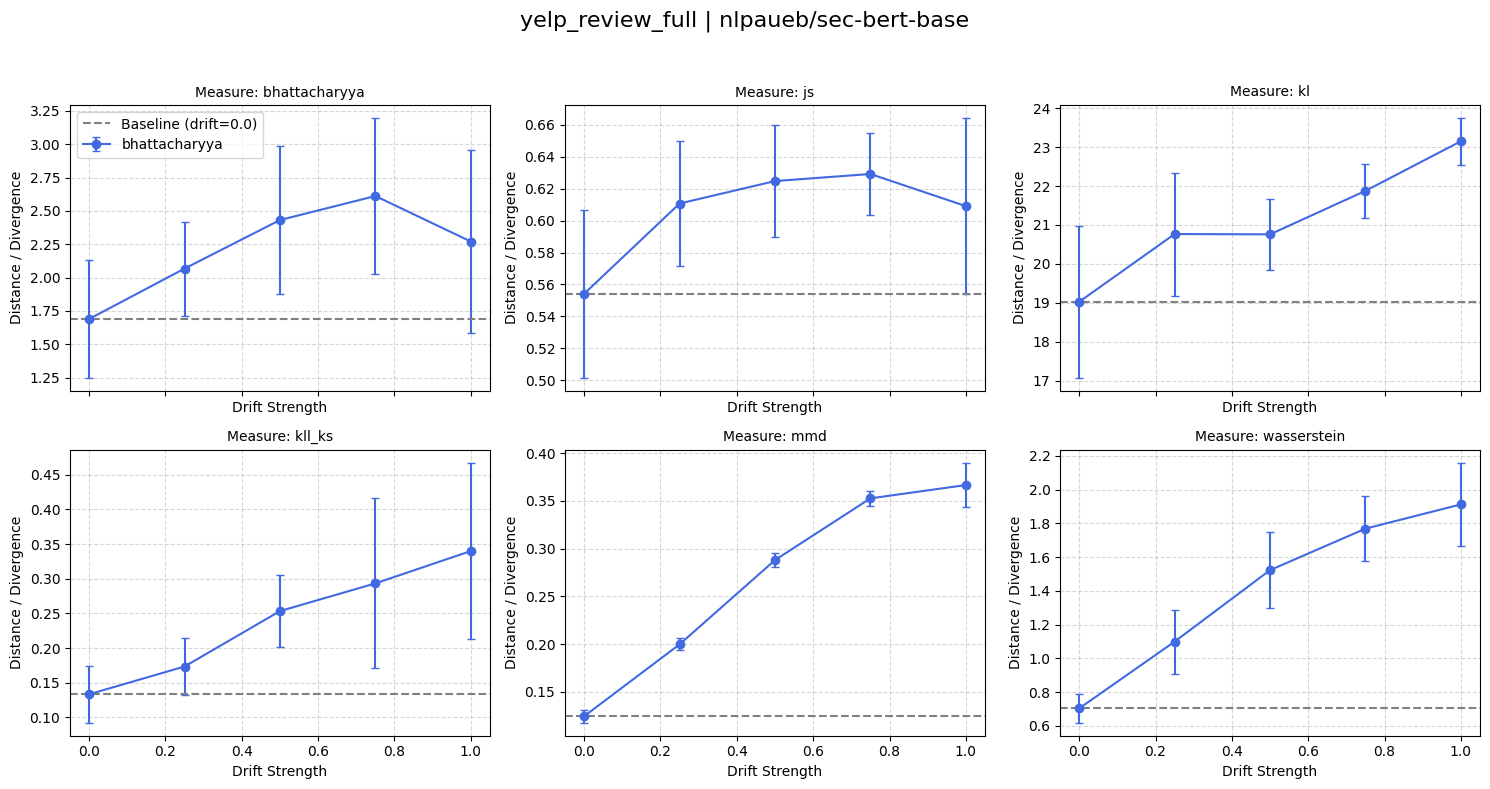

Saved figure: data-analysis/data/yelp_review_full_nlpaueb_sec-bert-base_distribution_measures.png


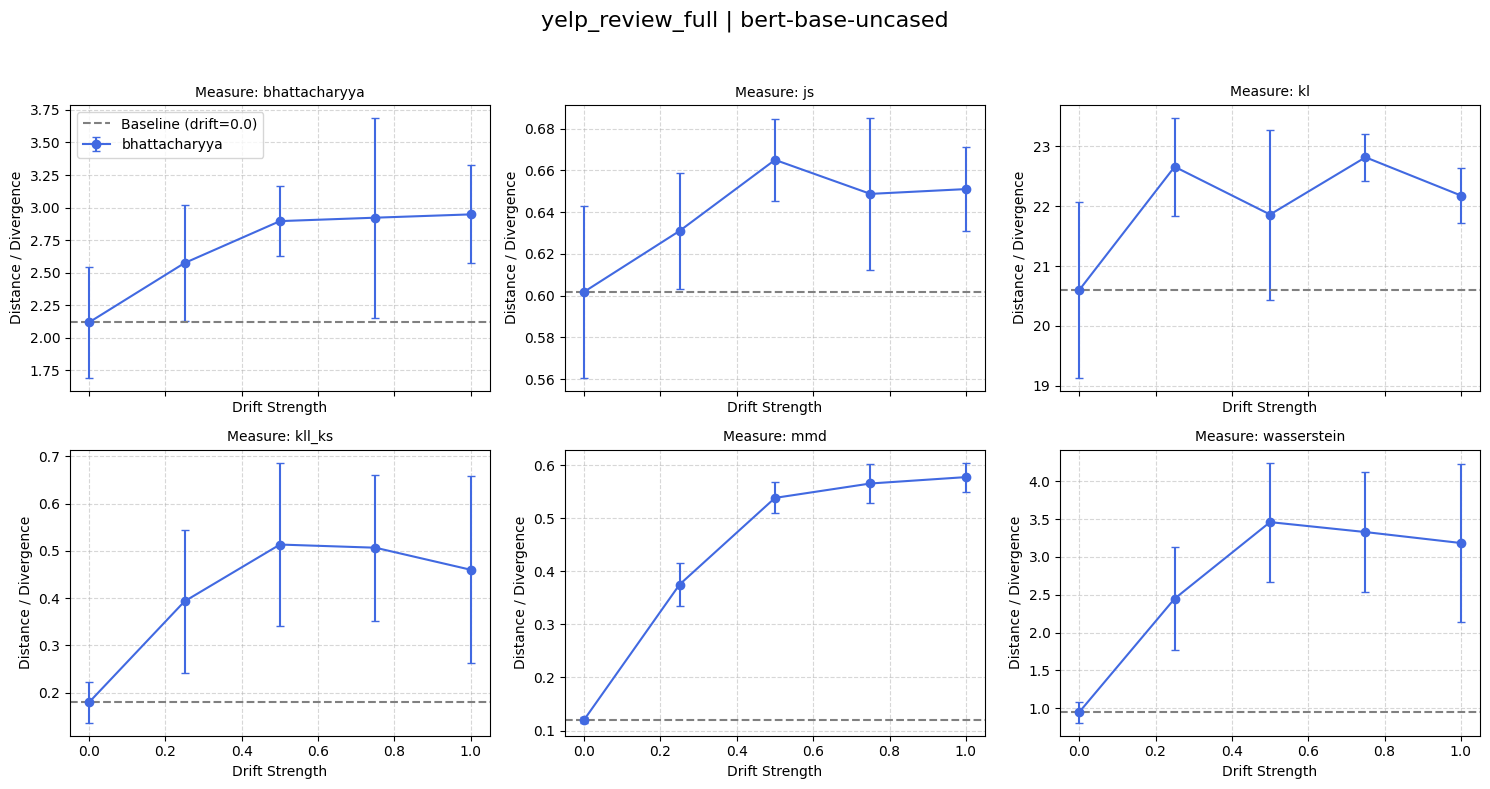

Saved figure: data-analysis/data/yelp_review_full_bert-base-uncased_distribution_measures.png


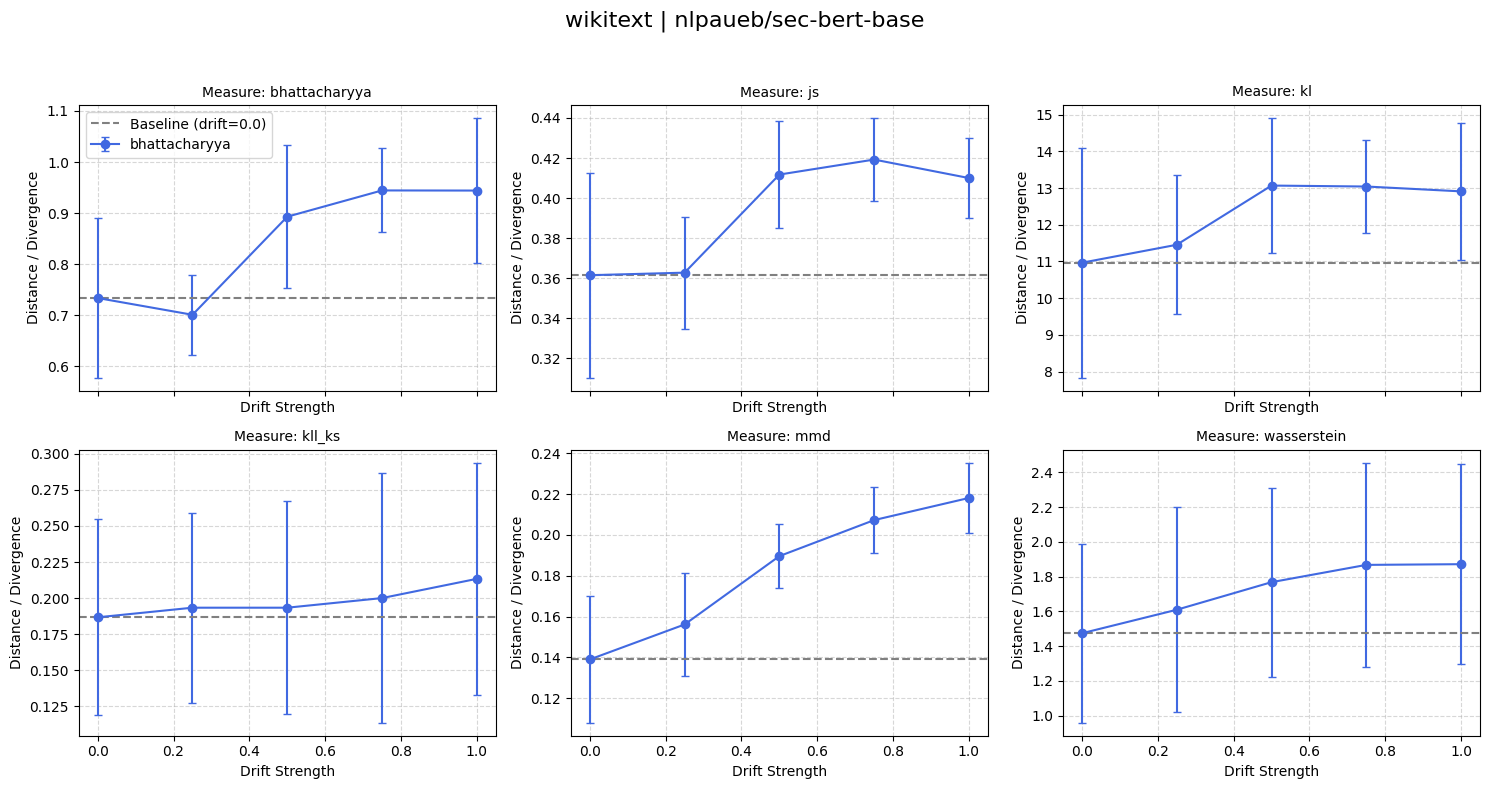

Saved figure: data-analysis/data/wikitext_nlpaueb_sec-bert-base_distribution_measures.png


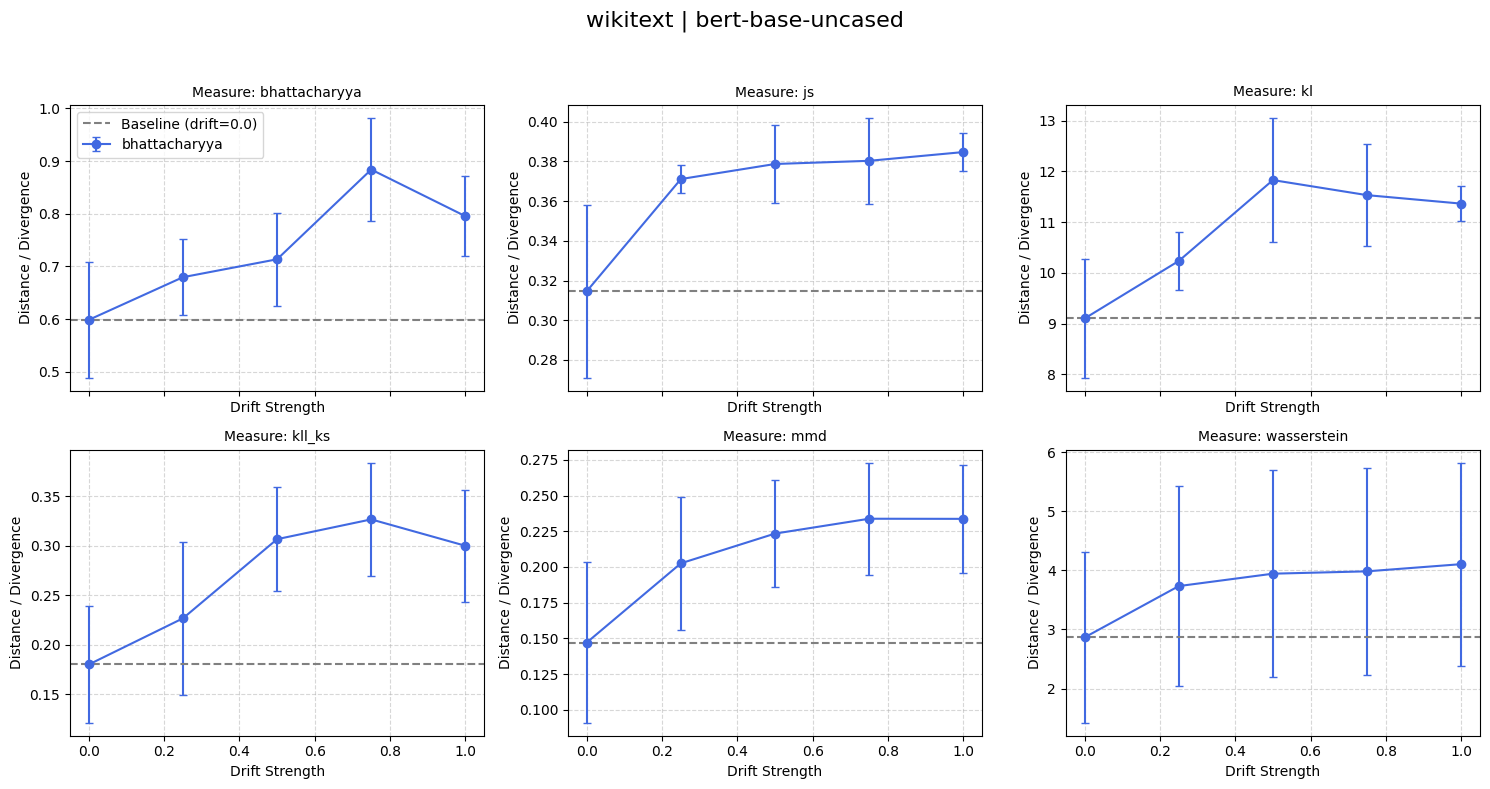

Saved figure: data-analysis/data/wikitext_bert-base-uncased_distribution_measures.png


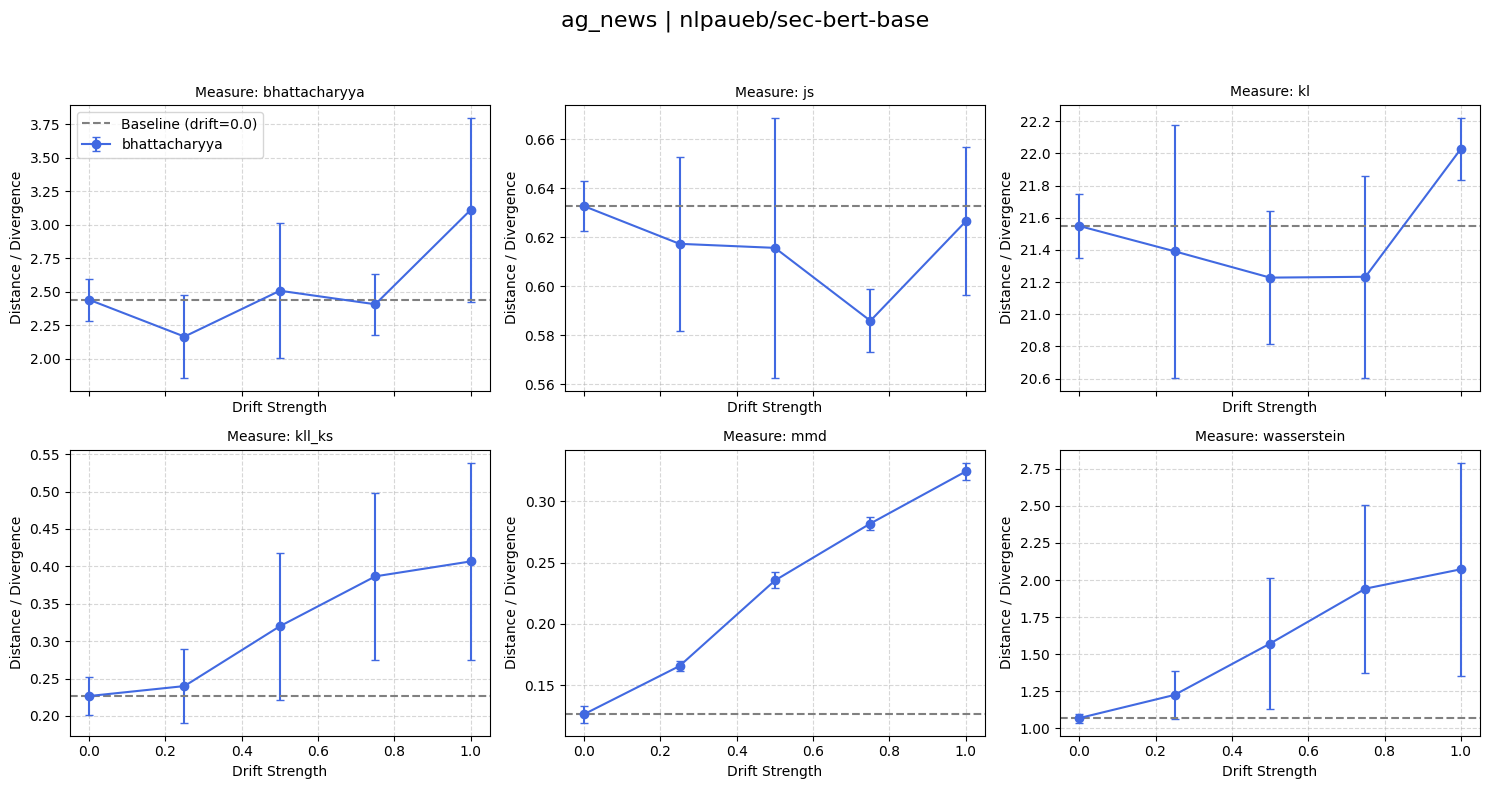

Saved figure: data-analysis/data/ag_news_nlpaueb_sec-bert-base_distribution_measures.png


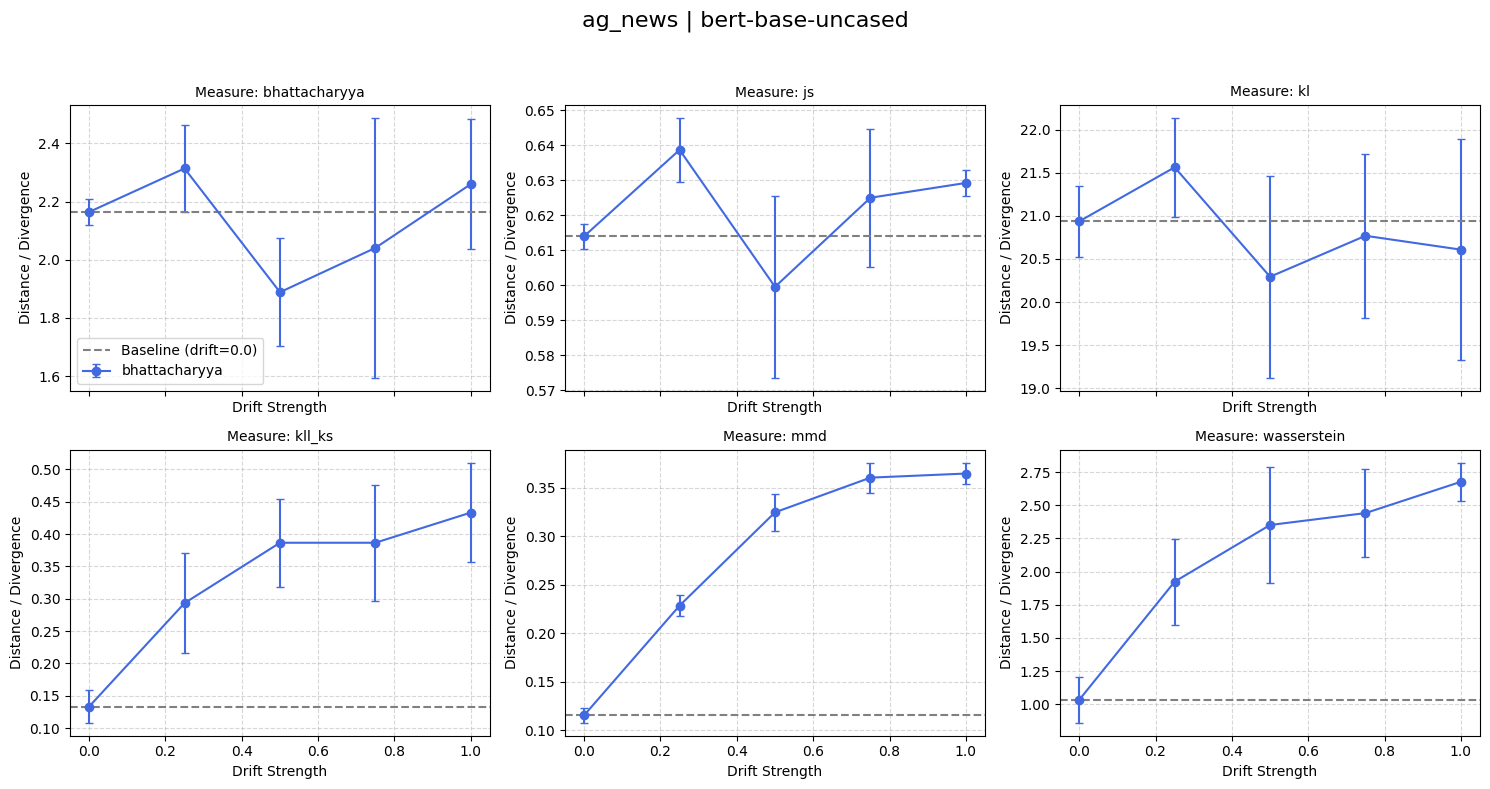

Saved figure: data-analysis/data/ag_news_bert-base-uncased_distribution_measures.png


In [2]:
###############################################################################
# 7) Plot with Error Bars (Updated)
###############################################################################
import os
import math
from collections import defaultdict


def plot_distribution_distances(all_results, args):
    """
    Plots distance metrics from `all_results`, which has keys of the form:
       (dataset_name, model_name, measure_name, drift_strength)
    and values that are lists of dictionaries like:
       [{"dist_val": ..., "time_taken": ..., "measure_overhead": ..., "seed": ...}, ...].

    We group by (dataset_name, model_name). For each measure, we plot:
       - error bars across drift_strength
       - where y-values are the mean of the distance values (dist_val)
       - and y-error is the standard deviation across seeds.

    The resulting figures are saved into args["output_dir"].

    Updates:
      - Draws a horizontal reference line for the baseline (drift=0.0).
      - Adds improved subplot labeling and grid usage.
    """
    # 1) Collect data into a structure for plotting
    #    plot_data[(dataset_name, model_name)][measure_name] = [(drift_strength, mean_val, std_val), ...]
    plot_data = defaultdict(lambda: defaultdict(list))

    for (
        dataset_name,
        model_name,
        measure_name,
        drift_strength,
    ), records in all_results.items():
        # records is a list of dicts, e.g. [{"dist_val": 0.1, "time_taken": 2.5, ...}, ...]
        # Extract just the dist_val for each seed
        dist_vals = [r["dist_val"] for r in records if r["dist_val"] is not None]

        if len(dist_vals) == 0:
            mean_val, std_val = 0.0, 0.0
        else:
            mean_val = np.mean(dist_vals)
            std_val = np.std(dist_vals)

        plot_data[(dataset_name, model_name)][measure_name].append(
            (drift_strength, mean_val, std_val)
        )

    # 2) For each (dataset_name, model_name), produce subplots for each measure
    for (dataset_name, model_name), measure_dict in plot_data.items():
        measure_names = sorted(measure_dict.keys())  # e.g., ["kl", "js", "mmd", ...]
        n_measures = len(measure_names)

        # Arrange subplots in a grid
        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)

        fig, axs = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True
        )
        axs = np.array(axs).flatten()  # flatten to iterate easily

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        # 3) Plot each measure in its own subplot
        for i, measure_name in enumerate(measure_names):
            ax = axs[i]
            data_points = measure_dict[measure_name]

            # Sort by drift_strength so the line is drawn in ascending order
            data_points.sort(key=lambda x: x[0])
            drift_strengths = [dp[0] for dp in data_points]
            y_means = [dp[1] for dp in data_points]
            y_stds = [dp[2] for dp in data_points]

            # Plot with error bars
            ax.errorbar(
                drift_strengths,
                y_means,
                yerr=y_stds,
                fmt="-o",
                capsize=3,
                label=measure_name,
                color="royalblue",
            )
            ax.set_title(f"Measure: {measure_name}", fontsize=10)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance / Divergence")
            ax.grid(True, linestyle="--", alpha=0.5)

            # 3a) Draw a horizontal line at the baseline drift=0.0, if present
            baseline_points = [dp for dp in data_points if dp[0] == 0.0]
            if baseline_points:
                baseline_mean = baseline_points[0][1]  # mean_val for drift=0.0
                ax.axhline(
                    y=baseline_mean,
                    color="gray",
                    linestyle="--",
                    label="Baseline (drift=0.0)",
                )

            if i == 0:
                ax.legend()

        # Hide any unused subplots (if #measures < n_rows*n_cols)
        for j in range(len(measure_names), n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # 4) Save figure
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path)
        plt.show()
        print(f"Saved figure: {save_path}")


# Finally, call the plot function with your results:
plot_distribution_distances(all_results, args)

In [3]:
import pandas as pd
import os

# Convert defaultdict to a structured DataFrame
rows = []
for (dataset, model, measure, drift_strength), records in all_results.items():
    # Extract the numeric 'dist_val' from each record
    for record in records:
        dist_val = record.get("dist_val")  # Safely get the distance value
        if dist_val is not None:
            rows.append([dataset, model, measure, drift_strength, dist_val])

# Create DataFrame
df = pd.DataFrame(
    rows, columns=["Dataset", "Model", "Measure", "Drift Strength", "Value"]
)

# Group by Dataset, Model, Measure, and Drift Strength, then compute mean and std
df_aggregated = (
    df.groupby(["Dataset", "Model", "Measure", "Drift Strength"])
    .agg(Mean_Value=("Value", "mean"), Std_Value=("Value", "std"))
    .reset_index()
)

# Save to CSV
save_path = os.path.join(args["output_dir"], "all_results_distribution_aggregated.csv")
df_aggregated.to_csv(save_path, index=False)

print(f"Saved aggregated data to: {save_path}")

# Display the aggregated DataFrame
print(df_aggregated)

Saved aggregated data to: data-analysis/data/all_results_distribution_aggregated.csv
              Dataset                  Model        Measure  Drift Strength  \
0             ag_news      bert-base-uncased  bhattacharyya            0.00   
1             ag_news      bert-base-uncased  bhattacharyya            0.25   
2             ag_news      bert-base-uncased  bhattacharyya            0.50   
3             ag_news      bert-base-uncased  bhattacharyya            0.75   
4             ag_news      bert-base-uncased  bhattacharyya            1.00   
..                ...                    ...            ...             ...   
175  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.00   
176  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.25   
177  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.50   
178  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.75   
179  yelp_review_full  nlpaueb/sec-bert-base  

In [4]:
def save_results_to_csv(all_results, args):
    """
    Save the results to a CSV file for further analysis.
    """
    summary_data = []

    # Aggregate results across all datasets and models
    for (
        dataset_name,
        model_name,
        measure_name,
        drift_strength,
    ), values in all_results.items():
        numeric_values = [v for v in values if isinstance(v, (int, float))]
        mean_val = np.mean(numeric_values)
        std_val = np.std(numeric_values)
        summary_data.append(
            (dataset_name, model_name, measure_name, drift_strength, mean_val, std_val)
        )

    # Convert to Pandas DataFrame
    df = pd.DataFrame(
        summary_data,
        columns=["Dataset", "Model", "Measure", "Drift Strength", "Mean", "Std"],
    )

    df.head()

    # Save to CSV for further analysis
    save_path = os.path.join(args["output_dir"], "all_results_distribution.csv")
    df.to_csv(save_path, index=False)
    print(f"Saved summary table to: {save_path}")


# Example usage
# save_results_to_csv(all_results, args)

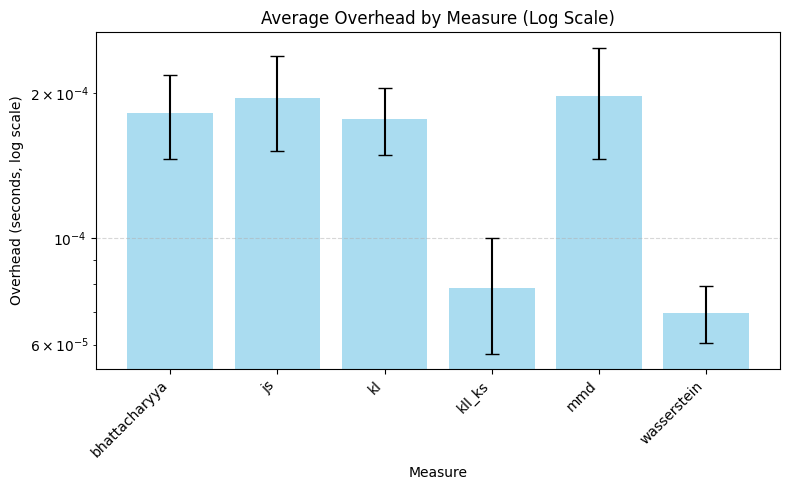

Saved results to: data-analysis/data-test/average_overhead_distribution.csv


In [5]:
import pandas as pd


def visualize_average_overhead_by_measure(all_results, output_csv_path):
    """
    Collapse across datasets, models, and drift_strength,
    and produce a bar chart of average overhead per measure (log scale).
    Save the results to a CSV file.
    """

    # 1) Convert 'all_results' into a pandas DataFrame
    rows = []
    for (dataset, model, measure, drift_strength), records in all_results.items():
        for rec in records:
            rows.append(
                {
                    "dataset": dataset,
                    "model": model,
                    "measure": measure,
                    "drift_strength": drift_strength,
                    "dist_val": rec["dist_val"],
                    "time_taken": rec["time_taken"],
                    "measure_overhead": rec["measure_overhead"],
                    "seed": rec["seed"],
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        print("No results to visualize. DataFrame is empty.")
        return

    # 2) Group by just 'measure' (ignore dataset/model/drift_strength)
    #    and compute mean & std for measure_overhead
    grouped = (
        df.groupby("measure")["measure_overhead"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "overhead_mean", "std": "overhead_std"})
    )

    # 3) Create a bar plot (with error bars) for overhead per measure
    plt.figure(figsize=(8, 5))

    # X positions for each measure on the bar chart
    x_positions = range(len(grouped))

    # Bar chart
    plt.bar(
        x_positions,
        grouped["overhead_mean"],
        yerr=grouped["overhead_std"],
        capsize=5,
        alpha=0.7,
        color="skyblue",
    )

    # Apply log scale
    plt.yscale("log")  # <-- LOG SCALE applied

    # Label the x-axis with measure names
    plt.xticks(ticks=x_positions, labels=grouped["measure"], rotation=45, ha="right")

    plt.title("Average Overhead by Measure (Log Scale)")
    plt.xlabel("Measure")
    plt.ylabel("Overhead (seconds, log scale)")
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

    # Save the grouped DataFrame to a CSV file
    grouped.to_csv(output_csv_path, index=False)
    print(f"Saved results to: {output_csv_path}")

    return grouped


# Example usage:
output_csv_path = "data-analysis/data-test/average_overhead_distribution.csv"
grouped_df = visualize_average_overhead_by_measure(all_results, output_csv_path)